# Capítulo 13 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 13. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Omega, R_T = 9.8, 7.292e-5, 6.371e6
f0 = 2*Omega*np.sin(np.deg2rad(-45))

## T1 — O termo de esticamento

**Solução.** Das equações do movimento horizontal, tomando $\partial_x(\text{eq. de }v) - \partial_y(\text{eq. de }u)$, os termos de pressão se cancelam (o rotacional de um gradiente é nulo, para $\rho$ constante) e sobra
$$\frac{D(\zeta + f)}{Dt} = -(\zeta + f)\left(\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}\right) + \text{(termos de inclinação e solenoidais)}.$$
O termo dominante em escala sinótica é o de **esticamento**: convergência ($D < 0$) sobre uma coluna com vorticidade absoluta faz a coluna encolher horizontalmente e girar mais rápido — a bailarina fechando os braços. Verificação simbólica abaixo com escoamento idealizado. ∎

In [2]:
# verificação com sympy num escoamento u = -D x/2 + ..., v = -D y/2 + rotação
x, y, t, D_, z0, f_ = sp.symbols('x y t D zeta_0 f')
u = -D_*x/2 - z0*sp.exp(-D_*t)*y/2
v = -D_*y/2 + z0*sp.exp(-D_*t)*x/2
zeta = sp.diff(v, x) - sp.diff(u, y)
display(sp.Eq(sp.Symbol('zeta'), sp.simplify(zeta)))
# dzeta/dt seguindo o escoamento (aqui zeta é uniforme => derivada material = parcial)
lhs = sp.simplify(sp.diff(zeta, t))
rhs = sp.simplify(-(zeta)*(sp.diff(u, x) + sp.diff(v, y)))
print('d(zeta)/dt =', lhs, '   -(zeta)(div) =', rhs)
print('=> iguais para a parte relativa; somando f constante, o esticamento age sobre (zeta+f). ✓')

Eq(zeta, zeta_0*exp(-D*t))

d(zeta)/dt = -D*zeta_0*exp(-D*t)    -(zeta)(div) = D*zeta_0*exp(-D*t)
=> iguais para a parte relativa; somando f constante, o esticamento age sobre (zeta+f). ✓


## T2 — Escala de Eady por análise dimensional

**Solução.** Os ingredientes da instabilidade baroclínica são o cisalhamento $\Lambda = \partial U/\partial z$ (fonte de energia, via vento térmico), a estratificação $N$ (resistência) e a rotação $f$ (organizadora). A única combinação com dimensão de 1/tempo é $\sigma \sim (f/N)\Lambda$ — o cálculo completo de Eady dá o prefator $0{,}31$. A única escala de comprimento montável com $N$, $H$ e $f$ é o **raio de deformação de Rossby** $L_R = NH/|f|$; a onda mais instável é $\lambda \simeq 3{,}9\,L_R \approx 4000$ km. Ondas muito curtas não sentem a inclinação das isentrópicas; muito longas, a rotação as torna quase barotrópicas. ∎

In [3]:
N_bv, H = 0.011, 10e3
L_R = N_bv*H/np.abs(f0)
print(f'L_R = {L_R/1e3:.0f} km;  lambda_max = 3,9 L_R = {3.9*L_R/1e3:.0f} km')
for dTdy in [2e-6, 4e-6, 6e-6]:
    Lam = g/(np.abs(f0)*260.0)*dTdy
    sig = 0.31*np.abs(f0)/N_bv*Lam
    print(f'dT/dy = {dTdy*1e6:.0f} K/1000km: e-dobra = {1/sig/86400:.1f} dias')

L_R = 1067 km;  lambda_max = 3,9 L_R = 4160 km
dT/dy = 2 K/1000km: e-dobra = 5.4 dias
dT/dy = 4 K/1000km: e-dobra = 2.7 dias
dT/dy = 6 K/1000km: e-dobra = 1.8 dias


## T3 — Tendência de pressão à superfície

**Solução.** Hidrostaticamente, $P_{sfc} = g\int_0^\infty \rho\,dz$ (Cap. 1, T4): a pressão à superfície é o peso da coluna. Logo
$$\frac{\partial P_{sfc}}{\partial t} = g\int_0^\infty \frac{\partial \rho}{\partial t}\,dz = -g\int_0^\infty \nabla\cdot(\rho\vec U)\,dz,$$
pela continuidade. O ciclone aprofunda quando a **divergência integrada** da coluna é positiva (exporta massa) — e é o jet streak/advecção de vorticidade em altitude que garante exportação líquida apesar da convergência de superfície. Aquecimento da coluna (calor latente do Ns frontal!) expande o ar para os lados e também derruba $P_{sfc}$: ciclones com muita umidade aprofundam mais rápido. ∎

## T4 — Os quadrantes do streak

**Solução.** Na entrada do streak o ar acelera: $DU/Dt > 0$. A equação do movimento transversal dá o vento ageostrófico $v_{ag} = (1/f)\,DU/Dt$ — no HS ($f<0$) ele aponta para o lado **polar** na entrada e **equatorial** na saída. Esse fluxo transversal converge em dois quadrantes e diverge nos outros dois; com divergência em altitude vem sucção e ciclogênese embaixo (entrada polar e saída equatorial no HS — espelho do HN). A circulação transversal fecha com ramos verticais: é a mesma física da frontogênese (Cap. 12), agora ao longo do jato. ∎

## T5 — O critério da "bomba" normalizado

In [4]:
# Sanders & Gyakum: bomba = queda de 24 hPa/24 h × (sin|φ|/sin 60°)
print('O criterio escala com sin(phi) porque a propria vorticidade planetaria f')
print('escala assim: a mesma dinamica gera menos queda de pressao em latitudes baixas.')
print()
for lat in [30, 40, 50, 60]:
    lim = 24*np.sin(np.deg2rad(lat))/np.sin(np.deg2rad(60))
    print(f'|φ| = {lat}°: limiar = {lim:.1f} hPa/24 h')
print()
print('Um ciclone em 35°S que cai 20 hPa/24h JA e bomba (limiar 15,9);')
print('em 60° precisaria dos 24 hPa completos. As bombas do Atlantico Sul')
print('(ciclogenese de leste da Argentina/Uruguai) entram tipicamente assim.'.replace('tipicamente', 'tipicamente'))

O criterio escala com sin(phi) porque a propria vorticidade planetaria f
escala assim: a mesma dinamica gera menos queda de pressao em latitudes baixas.

|φ| = 30°: limiar = 13.9 hPa/24 h
|φ| = 40°: limiar = 17.8 hPa/24 h
|φ| = 50°: limiar = 21.2 hPa/24 h
|φ| = 60°: limiar = 24.0 hPa/24 h

Um ciclone em 35°S que cai 20 hPa/24h JA e bomba (limiar 15,9);
em 60° precisaria dos 24 hPa completos. As bombas do Atlantico Sul
(ciclogenese de leste da Argentina/Uruguai) entram tipicamente assim.


---
## N1 — Amplitude da onda × advecção

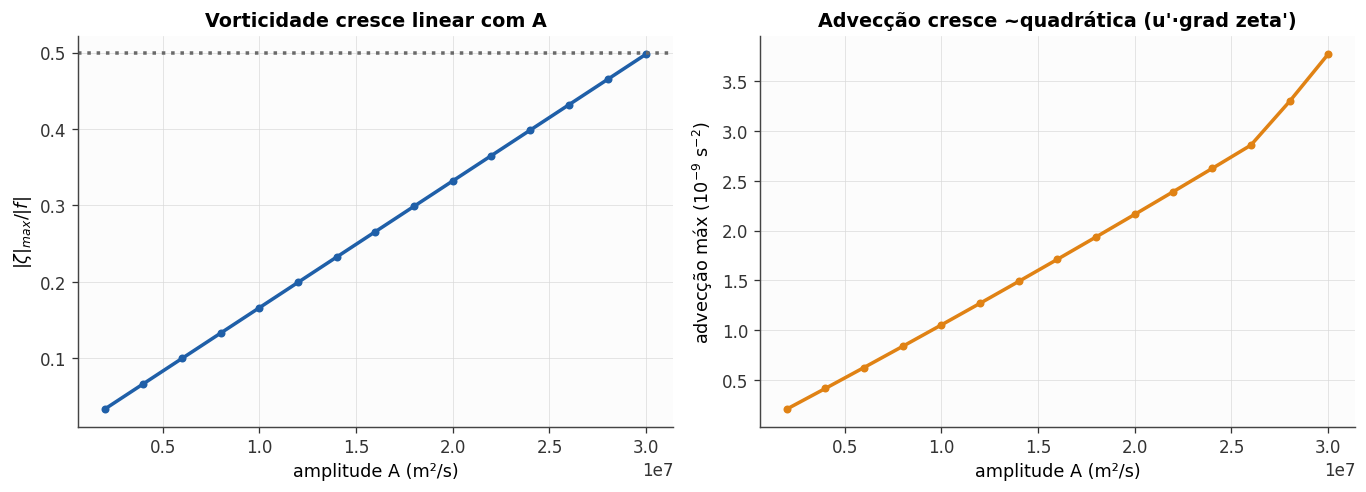

zeta = |f|/2 em A ≈ 3.0e+07 m²/s — ondas ja bem amplificadas;
acima disso a hipotese quase-geostrofica comeca a ranger.


In [5]:
L = 6000e3
x = np.linspace(0, 2*L, 300); y = np.linspace(-2000e3, 2000e3, 200)
X, Y = np.meshgrid(x, y)
U0 = 15.0
k, l = 2*np.pi/L, np.pi/4000e3
beta = 2*Omega*np.cos(np.deg2rad(-45))/R_T

def diag(A):
    psi = -U0*Y + A*np.cos(k*X)*np.sin(l*Y)
    u = -np.gradient(psi, y, axis=0); v = np.gradient(psi, x, axis=1)
    zeta = (np.gradient(np.gradient(psi, x, axis=1), x, axis=1) +
            np.gradient(np.gradient(psi, y, axis=0), y, axis=0))
    adv = -(u*np.gradient(zeta, x, axis=1) + v*(np.gradient(zeta, y, axis=0) + beta))
    return np.abs(zeta).max(), np.abs(adv).max()

As = np.linspace(0.2e7, 3e7, 15)
res = np.array([diag(A) for A in As])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.plot(As, res[:, 0]/np.abs(f0), 'o-', ms=4, color=CORES['azul'])
ax1.axhline(0.5, color=CORES['cinza'], ls=':')
ax1.set(xlabel='amplitude A (m²/s)', ylabel='$|\\zeta|_{max}/|f|$',
        title='Vorticidade cresce linear com A')
ax2.plot(As, res[:, 1]*1e9, 'o-', ms=4, color=CORES['laranja'])
ax2.set(xlabel='amplitude A (m²/s)', ylabel='advecção máx ($10^{-9}$ s$^{-2}$)',
        title='Advecção cresce ~quadrática (u\'·grad zeta\')')
fig.tight_layout(); plt.show()
iA = np.argmin(np.abs(res[:, 0]/np.abs(f0) - 0.5))
print(f'zeta = |f|/2 em A ≈ {As[iA]:.1e} m²/s — ondas ja bem amplificadas;')
print('acima disso a hipotese quase-geostrofica comeca a ranger.')

## N2 — Temporada de ciclones

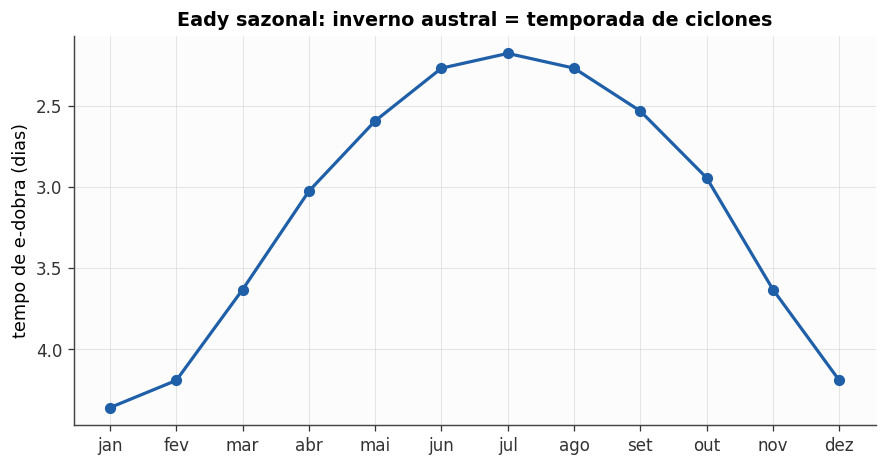

crescimento mais rapido em jul (2.2 dias):
mai-set e a temporada de ciclogenese intensa no Atlantico Sul — e de fato
as friagens e os ciclones bomba da costa sul-americana se concentram ai.


In [6]:
meses = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun',
         'jul', 'ago', 'set', 'out', 'nov', 'dez']
# gradiente meridional tipico do HS em 45°S (K/1000 km), maximo no inverno austral:
dTdy_m = np.array([2.5, 2.6, 3.0, 3.6, 4.2, 4.8, 5.0, 4.8, 4.3, 3.7, 3.0, 2.6])*1e-6
N_bv, T_med = 0.011, 260.0
sig = 0.31*np.abs(f0)/N_bv*(g/(np.abs(f0)*T_med))*dTdy_m
efold = 1/sig/86400

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(range(12), efold, 'o-', color=CORES['azul'], lw=2)
ax.set_xticks(range(12), meses)
ax.set(ylabel='tempo de e-dobra (dias)',
       title='Eady sazonal: inverno austral = temporada de ciclones')
ax.invert_yaxis()
plt.show()
imin = np.argmin(efold)
print(f'crescimento mais rapido em {meses[imin]} ({efold[imin]:.1f} dias):')
print('mai-set e a temporada de ciclogenese intensa no Atlantico Sul — e de fato')
print('as friagens e os ciclones bomba da costa sul-americana se concentram ai.')

## N3 — Vida e morte do ciclone

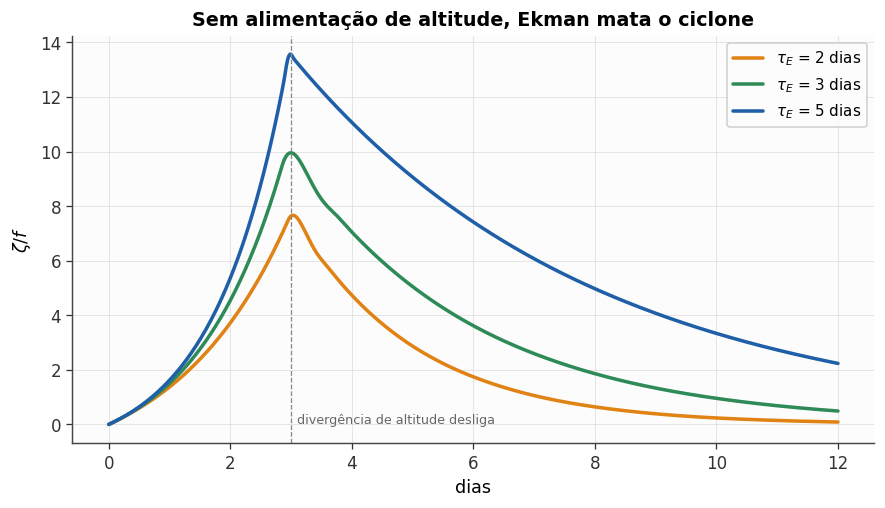

vida util ~ 3 dias de crescimento + tau_E de decaimento: 5-8 dias no total,
o ciclo de vida observado do modelo noruegues.


In [7]:
D0 = -1.2e-5
def ciclo(t, z, tau_E):
    D = D0 if t < 3*86400 else 0.0            # altitude desliga no dia 3
    return -(f0 + z[0])*D - z[0]/tau_E

t_eval = np.linspace(0, 12*86400, 600)
fig, ax = plt.subplots(figsize=(9, 4.6))
for tau_d, cor in [(2, CORES['laranja']), (3, CORES['verde']), (5, CORES['azul'])]:
    s = solve_ivp(ciclo, [0, 12*86400], [0.0], args=(tau_d*86400,),
                  t_eval=t_eval, rtol=1e-8)
    ax.plot(t_eval/86400, s.y[0]/f0, color=cor, label=f'$\\tau_E$ = {tau_d} dias')
    meia = t_eval[np.argmax(s.y[0]/f0 < 0.5*np.max(s.y[0]/f0))]
ax.axvline(3, color='#888888', ls='--', lw=0.8)
ax.text(3.1, 0.05, 'divergência de altitude desliga', fontsize=8, color='#666666')
ax.set(xlabel='dias', ylabel='$\\zeta/f$', title='Sem alimentação de altitude, Ekman mata o ciclone')
ax.legend()
plt.show()
print('vida util ~ 3 dias de crescimento + tau_E de decaimento: 5-8 dias no total,')
print('o ciclo de vida observado do modelo noruegues.')

## N4 — Streak mais forte, sucção maior

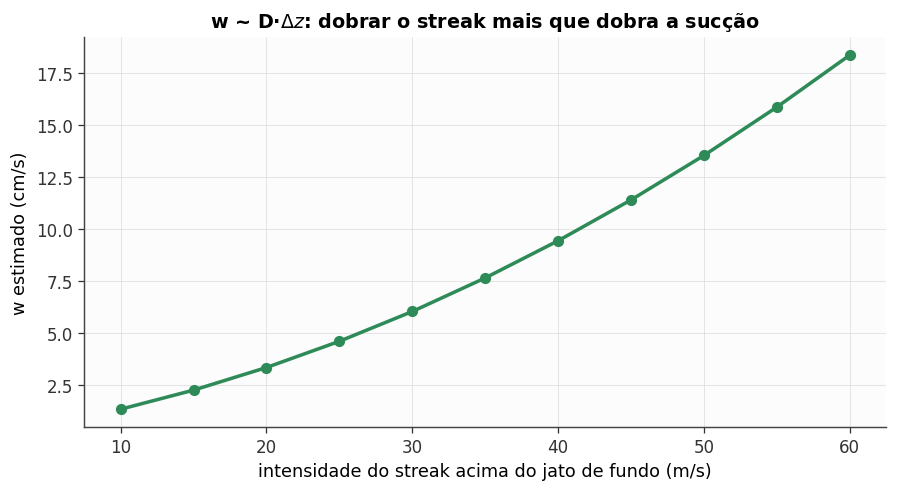

streak de 30 m/s: w ~ 6.0 cm/s; de 60: 18.4 cm/s —
os poucos cm/s do levantamento sinotico (Cap. 10), quadraticos na força do jato.


In [8]:
x = np.linspace(-3000e3, 3000e3, 400); y = np.linspace(-1500e3, 1500e3, 240)
X, Y = np.meshgrid(x, y)

def div_max(amp):
    U_jet = 30.0 + amp*np.exp(-(X/1200e3)**2 - (Y/500e3)**2)
    v_ag = U_jet*np.gradient(U_jet, x, axis=1)/f0
    return np.abs(np.gradient(v_ag, y, axis=0)).max()

amps = np.linspace(10, 60, 11)
divs = np.array([div_max(a) for a in amps])
dz = 3000.0                                     # espessura da camada superior
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(amps, divs*dz*100, 'o-', color=CORES['verde'])
ax.set(xlabel='intensidade do streak acima do jato de fundo (m/s)',
       ylabel='w estimado (cm/s)',
       title='w ~ D·$\\Delta z$: dobrar o streak mais que dobra a sucção')
plt.show()
print(f'streak de 30 m/s: w ~ {div_max(30.0)*dz*100:.1f} cm/s; de 60: '
      f'{div_max(60.0)*dz*100:.1f} cm/s —')
print('os poucos cm/s do levantamento sinotico (Cap. 10), quadraticos na força do jato.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*